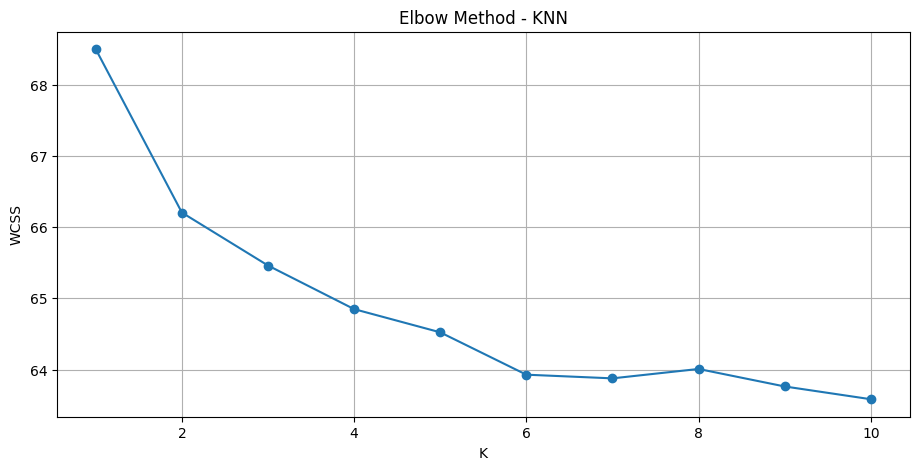

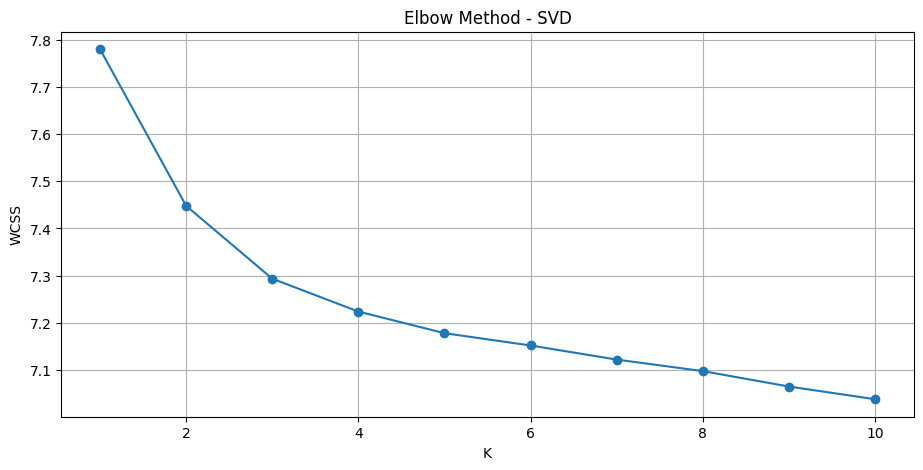

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn import metrics
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans

K_VALUES = list(range(1,11))
RANDOM_STATE = 1

FILES = {
    "KNN": "cf_filled_matrix_knn.csv",
    "SVD": "cf_filled_matrix_svd.csv",
}

def load_matrix(path):
    X = pd.read_csv(path, index_col=0).to_numpy(dtype=np.float32)
    return normalize(X, norm="l2", axis=1)

def elbow_inertia(X, k_values):
    inertias = []

    for k in k_values:
        km = KMeans(
            n_clusters=k,
            init="k-means++",
            random_state=RANDOM_STATE,
            n_init=5,
            max_iter=150,
        )
        km.fit(X)
        inertias.append(km.inertia_)

    return inertias


for name, path in FILES.items():
    X = load_matrix(path)
    inertias = elbow_inertia(X, K_VALUES)

    plt.figure(figsize=(11, 5))
    plt.plot(K_VALUES, inertias, marker="o")
    plt.title(f"Elbow Method - {name}")
    plt.xlabel("K")
    plt.ylabel("WCSS")
    plt.grid(True)
    plt.show()

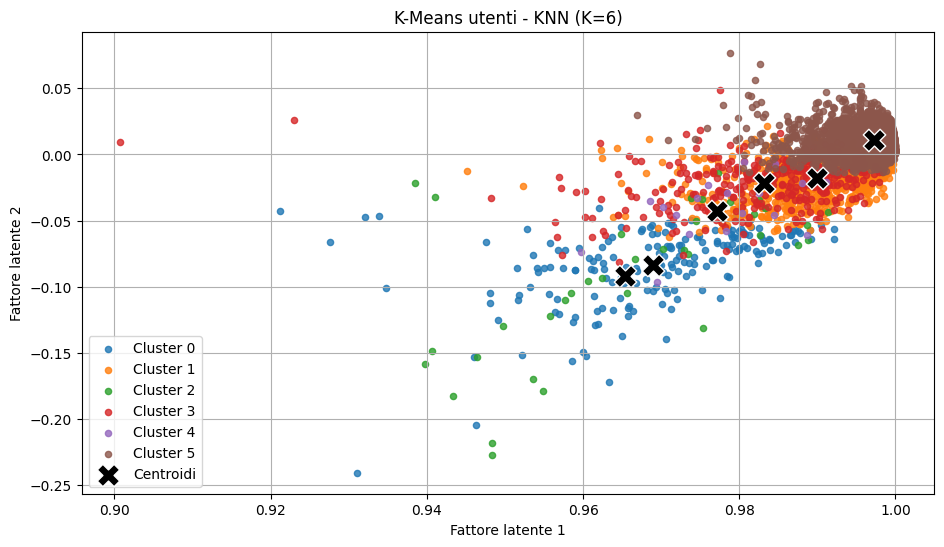

Silhouette score (KNN, K=6): 0.3458
 cluster  n_utenti  recensioni_medie  rating_medio
       0       186         29.854839      3.003617
       1       987         34.028369      3.832467
       2        36         35.805556      3.378400
       3       343         35.982507      3.759681
       4        20         34.750000      3.843470
       5      4146         34.298842      4.477847


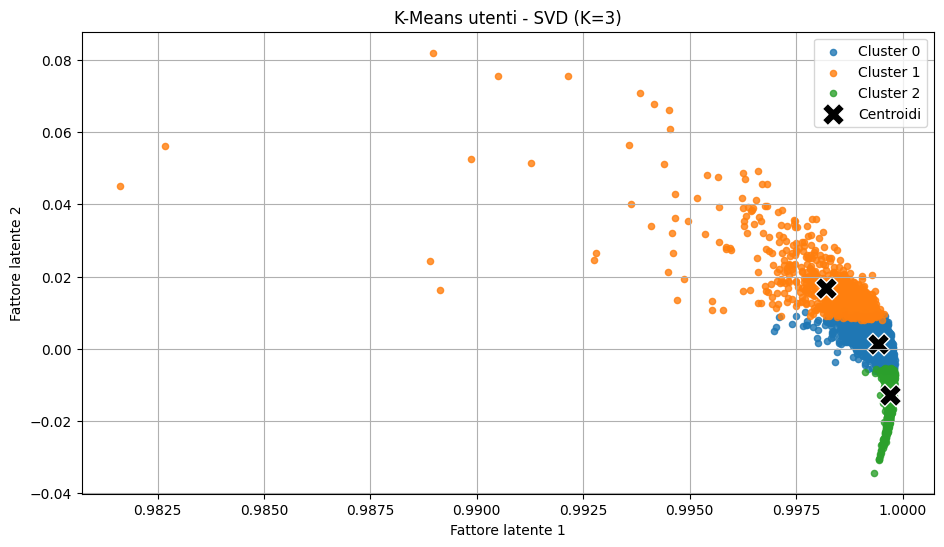

Silhouette score (SVD, K=3): -0.0674
 cluster  n_utenti  recensioni_medie  rating_medio
       0      3508         33.710661      4.259264
       1       807         37.786865      3.184623
       2      1403         33.440485      4.905947


In [10]:
OPTIMAL_K = {"KNN": 6, "SVD": 3}

reviews = pd.read_csv("reviews_clean.csv", usecols=["user_id", "rating"])
reviews["rating"] = reviews["rating"].astype(np.float32)

for dataset_name, dataset_path in FILES.items():
    df_filled = pd.read_csv(dataset_path, index_col=0)
    user_ids = df_filled.index.astype(str)

    X = normalize(df_filled.to_numpy(dtype=np.float32), norm="l2", axis=1)
    k = OPTIMAL_K[dataset_name]

    km = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=300,
    )
    labels = km.fit_predict(X)

    svd2 = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
    X_2d = svd2.fit_transform(X)
    centroids_2d = svd2.transform(km.cluster_centers_)

    plt.figure(figsize=(11, 6))
    for c in range(k):
        pts = X_2d[labels == c]
        plt.scatter(
            pts[:, 0],
            pts[:, 1],
            s=20,
            color=plt.cm.tab10(c),
            label=f"Cluster {c}",
            alpha=0.8,
        )

    plt.scatter(
        centroids_2d[:, 0],
        centroids_2d[:, 1],
        s=260,
        c="black",
        marker="X",
        edgecolors="white",
        linewidths=1,
        label="Centroidi",
    )

    plt.title(f"K-Means utenti - {dataset_name} (K={k})")
    plt.xlabel("Fattore latente 1")
    plt.ylabel("Fattore latente 2")
    plt.grid(True)
    plt.legend()
    plt.show()

    sil = metrics.silhouette_score(X, labels, metric="cosine")
    print(f"Silhouette score ({dataset_name}, K={k}): {sil:.4f}")

    label_map = pd.Series(labels, index=user_ids, name="cluster")

    reviews_sub = reviews[reviews["user_id"].astype(str).isin(user_ids)].copy()
    reviews_sub["cluster"] = reviews_sub["user_id"].astype(str).map(label_map).astype(int)

    per_user = (
        reviews_sub.groupby(["cluster", "user_id"], as_index=False)
        .agg(n_recensioni=("rating", "size"), rating_medio_utente=("rating", "mean"))
    )

    cluster_stats = (
        per_user.groupby("cluster", as_index=False)
        .agg(
            n_utenti=("user_id", "nunique"),
            recensioni_medie=("n_recensioni", "mean"),
            rating_medio=("rating_medio_utente", "mean"),
        )
        .sort_values("cluster")
        .reset_index(drop=True)
    )

    print(cluster_stats.to_string(index=False))